<a href="https://colab.research.google.com/github/fluorescentlightpower/mifi_homework/blob/main/%D0%A0%D0%B5%D0%B9%D1%82%D0%B8%D0%BD%D0%B3_%D0%BD%D0%B0%D1%81%D1%82%D0%BE%D0%BB%D1%8C%D0%BD%D1%8B%D1%85_%D0%B8%D0%B3%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import re
from google.colab import files
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA


np.random.seed(42)

In [42]:
files.upload()
!unzip games-rating.zip

Saving games-rating.zip to games-rating (1).zip
Archive:  games-rating.zip
replace sample_submition.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: sample_submition.csv    
  inflating: test_data.csv           
  inflating: train_data.csv          


Целые числа из исходных файлов распознаются как числа с плавающей точкой. Для преобразования удобно сделать функцию

In [93]:
def to_integer (dfi, cols=['Year Published', 'Owned Users']):
    df = dfi.copy()
    df[cols] = df[cols].apply(lambda col: pd.to_numeric(col, errors='coerce')).astype('Int64')
    return df

In [178]:
df_train = to_integer(pd.read_csv('train_data.csv', decimal=','))
df_test = to_integer(pd.read_csv('test_data.csv', decimal=','))

In [95]:
df_train.head(30)

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017,1,4,120,14,42055,8.79,1,3.86,68323,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,224517.0,Brass: Birmingham,2018,2,4,120,14,19217,8.66,3,3.91,28785,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
2,167791.0,Terraforming Mars,2016,1,5,120,12,64864,8.43,4,3.24,87099,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
3,233078.0,Twilight Imperium: Fourth Edition,2017,3,6,480,14,13468,8.70,5,4.22,16831,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"
4,291457.0,Gloomhaven: Jaws of the Lion,2020,1,4,120,14,8392,8.87,6,3.55,21609,"Action Queue, Campaign / Battle Card Driven, C...","Strategy Games, Thematic Games"
5,182028.0,Through the Ages: A New Story of Civilization,2015,2,4,120,14,23061,8.43,7,4.41,26985,"Action Points, Auction/Bidding, Auction: Dutch...",Strategy Games
6,220308.0,Gaia Project,2017,1,4,150,12,16352,8.49,8,4.35,20312,"End Game Bonuses, Hexagon Grid, Income, Modula...",Strategy Games
7,187645.0,Star Wars: Rebellion,2016,2,4,240,14,23081,8.42,9,3.71,34849,"Area Majority / Influence, Area Movement, Area...",Thematic Games
8,193738.0,Great Western Trail,2016,2,4,150,12,29457,8.30,11,3.71,35804,"Deck Bag and Pool Building, Hand Management, O...",Strategy Games
9,162886.0,Spirit Island,2017,1,4,120,13,25722,8.35,13,4.01,38254,"Action Retrieval, Area Majority / Influence, C...",Strategy Games


In [96]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  15247 non-null  object 
 1   Name                15257 non-null  object 
 2   Year Published      15256 non-null  Int64  
 3   Min Players         15257 non-null  int64  
 4   Max Players         15257 non-null  int64  
 5   Play Time           15257 non-null  int64  
 6   Min Age             15257 non-null  int64  
 7   Users Rated         15257 non-null  int64  
 8   Rating Average      15257 non-null  float64
 9   BGG Rank            15257 non-null  int64  
 10  Complexity Average  15257 non-null  float64
 11  Owned Users         15240 non-null  Int64  
 12  Mechanics           14057 non-null  object 
 13  Domains             7608 non-null   object 
dtypes: Int64(2), float64(2), int64(6), object(4)
memory usage: 1.7+ MB


In [97]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5086 entries, 0 to 5085
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5080 non-null   object 
 1   Name                5086 non-null   object 
 2   Year Published      5086 non-null   Int64  
 3   Min Players         5086 non-null   int64  
 4   Max Players         5086 non-null   int64  
 5   Play Time           5086 non-null   int64  
 6   Min Age             5086 non-null   int64  
 7   Users Rated         5086 non-null   int64  
 8   BGG Rank            5086 non-null   int64  
 9   Complexity Average  5086 non-null   float64
 10  Owned Users         5080 non-null   Int64  
 11  Mechanics           4688 non-null   object 
 12  Domains             2576 non-null   object 
dtypes: Int64(2), float64(1), int64(6), object(4)
memory usage: 526.6+ KB


In [98]:
df_train.describe()

,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users
count,15256.0,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15240.0
mean,1984.14414,2.021236,5.642918,92.801337,9.581766,819.530773,6.399775,10186.327784,1.991064,1372.209843
std,211.725679,0.696323,12.551944,607.611378,3.671560,3286.396397,0.936488,5863.744570,0.848816,4681.296849
min,-3500.0,0.000000,0.000000,0.000000,0.000000,30.000000,1.050000,1.000000,0.000000,0.0
25%,2001.0,2.000000,4.000000,30.000000,8.000000,55.000000,5.820000,5103.000000,1.330000,146.0
50%,2011.0,2.000000,4.000000,45.000000,10.000000,119.000000,6.430000,10171.000000,2.000000,308.0
75%,2016.0,2.000000,6.000000,90.000000,12.000000,379.000000,7.020000,15280.000000,2.540000,856.25
max,2022.0,10.000000,999.000000,60000.000000,25.000000,102214.000000,9.580000,20344.000000,5.000000,155312.0


In [99]:
df_train.nunique()

,0
ID,15247
Name,15045
Year Published,164
Min Players,11
Max Players,49
Play Time,103
Min Age,21
Users Rated,2516
Rating Average,605
BGG Rank,15257


Есть пропуски в переменных. Год выпуска имеет отрицательные значения - видимо, относится к годам до нашей эры.

In [100]:
df_train.duplicated().sum() + df_test.duplicated().sum()

np.int64(0)

Полных дубликатов в обучающих данных нет. В годе выпуска есть один пропуск в обущающих данных. Удалим эту строку

In [101]:
df_train['Year Published'].isna().sum()

np.int64(1)

In [102]:
df_train.dropna(subset=['Year Published'], inplace=True)
# df_test.dropna(subset=['Year Published'], inplace=True)

Для baseline решения не будем использовать признак Domains, так как там много пропусков. Колонки ID и Name удалим, потому что там почти исключительно уникальные значения, они не имеют ценности для регрессии. Колонку BGG Rank будем рассматривать как опциональную. Сделаем 2 модели - с ней и без нее.

In [103]:
cols_drop = ['ID', 'Name', 'Domains']

cols_number = [
    'Year Published',
    'Min Players',
    'Max Players',
    'Play Time',
    'Min Age',
    'Users Rated',
    'Complexity Average',
    'Owned Users'
]

cols_optional = [
    'BGG Rank'
]

cols_multilabel = [
    'Mechanics'
]

In [104]:
# Все не буквенно-цифровые символы (\W) - это потенциальные разделители в колонке
all_separators = set()

for col in cols_multilabel:
    df_col = df_train[col].fillna('').astype(str)
    for value in df_col:
        found = re.findall(r'\W', value)
        all_separators.update(found)
print(sorted(all_separators))

[' ', "'", ',', '-', '/', ':']


В качестве разделителей встречаются только запятая и обратный слэш

In [105]:
class MultiLabelTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()
        self.unknown_token = 'Unknown'

    def _prepare_X (self, X):
        X_transformed = X.squeeze().fillna('').apply(
            lambda x: [item.strip() for item in re.split(r'[,/]', x) if item.strip()]
        )
        return X_transformed

    def fit(self, X, y=None):
        X_prepared = self._prepare_X(X)

        # В каждую строку добавляется Unknown, чтобы была возможность обрабатывать неизвестные категории.
        # Если нет неизвестных, для колонки Unknown при энкодинге будет 0 в данной строке
        X_prepared = X_prepared.apply(
            lambda labels: labels + [self.unknown_token]
        )
        self.mlb.fit(X_prepared)

        # Явное указание обученных атрибутов чтобы sklearn понимал, что эстиматор обучен и не выдавал предупреждений
        self.classes_ = self.mlb.classes_
        self.n_features_in_ = 1

        return self

    def transform(self, X):
        X_prepared = self._prepare_X(X)

        # Нужно добавить метку неизвестного класса, если он встречается в тестовой выборке, но отсутствует в обучающей
        def process_labels(labels):
            known_labels = []
            has_unknown = False

            for label in labels:
                if label in self.classes_:
                    known_labels.append(label)
                else:
                    has_unknown = True

            if has_unknown:
                known_labels.append(self.unknown_token)

            return known_labels

        # Кодирование как неизвестных для классов, для которых нет обучения
        X_processed = X_prepared.apply(process_labels)

        transformed = self.mlb.transform(X_processed)

        return pd.DataFrame(
            transformed,
            columns=self.classes_,
            index=X.index
        )

In [106]:
# Преобразование числовых признаков
number_pipeline = Pipeline([
    ('fill_na', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Преобразование признака механики
mechanics_pipeline = Pipeline([
    ('multilabel', MultiLabelTransformer())
])

# Преобразование признака домена
domains_pipeline = Pipeline([
    ('multilabel', MultiLabelTransformer())
])

# Общий предобработчик без опциональных признаков - указано, что делать для каждого типа колонок или отдельных колонок
preprocessor_min = ColumnTransformer([
    ('num', number_pipeline, cols_number),
    ('mechanics', mechanics_pipeline, ['Mechanics'])
    # ('domains', domains_pipeline, ['Domains'])
],
remainder='drop')

# Аналогичный общий предобработчик c опциональными признаками
preprocessor_opt = ColumnTransformer([
    ('num', number_pipeline, cols_number + cols_optional),
    ('mechanics', mechanics_pipeline, ['Mechanics'])
    # ('domains', domains_pipeline, ['Domains'])
],
remainder='drop')

Выделим тестовый набор из обучающей выборки

In [107]:
X = df_train.drop(columns=['Rating Average'] + cols_drop)
y = df_train['Rating Average']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Линейная регрессия и случайный лес в качестве baseline до анализа признаков и feature engineering

In [108]:
model_lin_reg = Pipeline([
    ('preprocessing', preprocessor_min),
    ('regressor', LinearRegression())
])

model_lin_reg.fit(X_train, y_train)

y_pred = model_lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'R2: {r2:.4f}')

MSE: 0.5772
R2: 0.3545


In [109]:
cv_mse = -cross_val_score(
                model_lin_reg,
                X,
                y,
                cv=5,
                scoring='neg_mean_squared_error'
            ).mean()

print(f'CV MSE: {cv_mse:.4f}')

cv_r2 = cross_val_score(
    model_lin_reg,
    X,
    y,
    cv=5,
    scoring='r2'
).mean()

print(f'CV R2: {cv_r2:.4f}')

CV MSE: 0.8690
CV R2: -1.4513


In [110]:
model_rnd_forest = Pipeline([
    ('preprocessing', preprocessor_min),
    ('regressor', RandomForestRegressor(n_estimators=300, random_state=42))
])

model_rnd_forest.fit(X_train, y_train)

y_pred = model_rnd_forest.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'R2: {r2:.4f}')

MSE: 0.4266
R2: 0.5229


Без обработки признаков линейная регрессия и случайный лес работают плохо, необходима обработка пропусков и выбросов, а также анализ распределений признаков

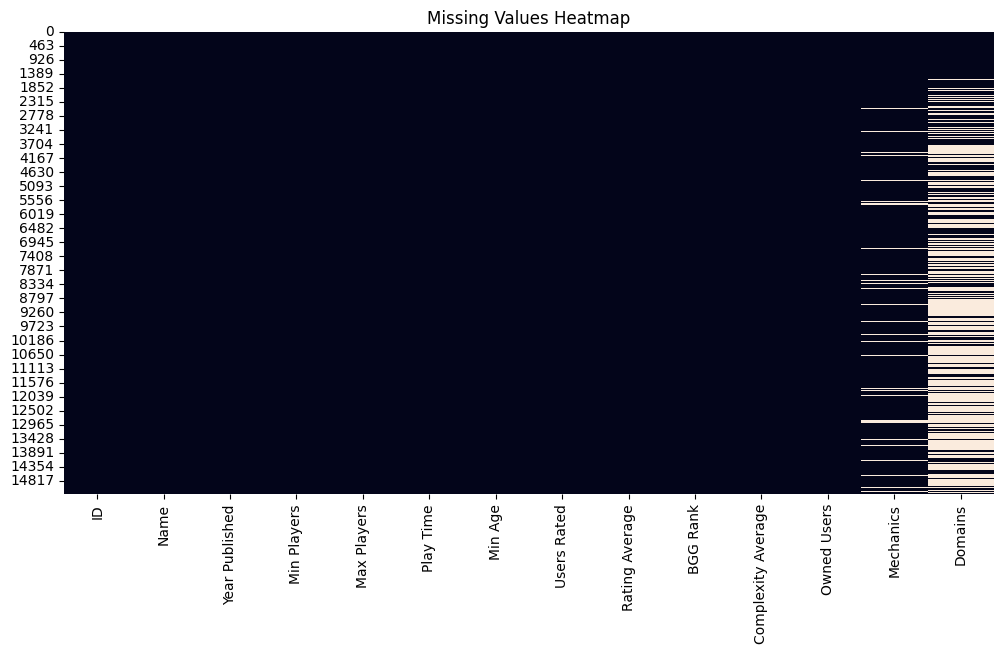

In [111]:
plt.figure(figsize=(12,6))
sns.heatmap(df_train.isna(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

Пропуски почти не коррелируют

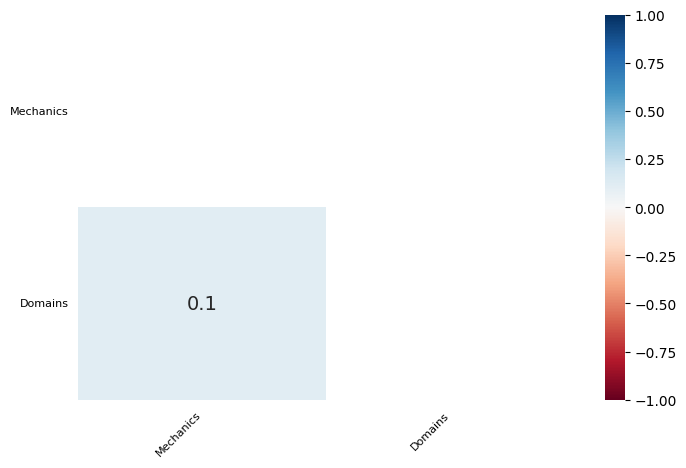

In [112]:
fig, ax = plt.subplots(figsize=(8, 5))
msno.heatmap(df_train[['Mechanics','Domains']], ax=ax)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

Возраст игры - более осмысленный с точки зрения интерпретации признак

In [179]:
df_train['Game age'] = 2026 - df_train['Year Published']
df_test['Game age'] = 2026 - df_test['Year Published']
df_train['Game age'].median()

np.float64(15.0)

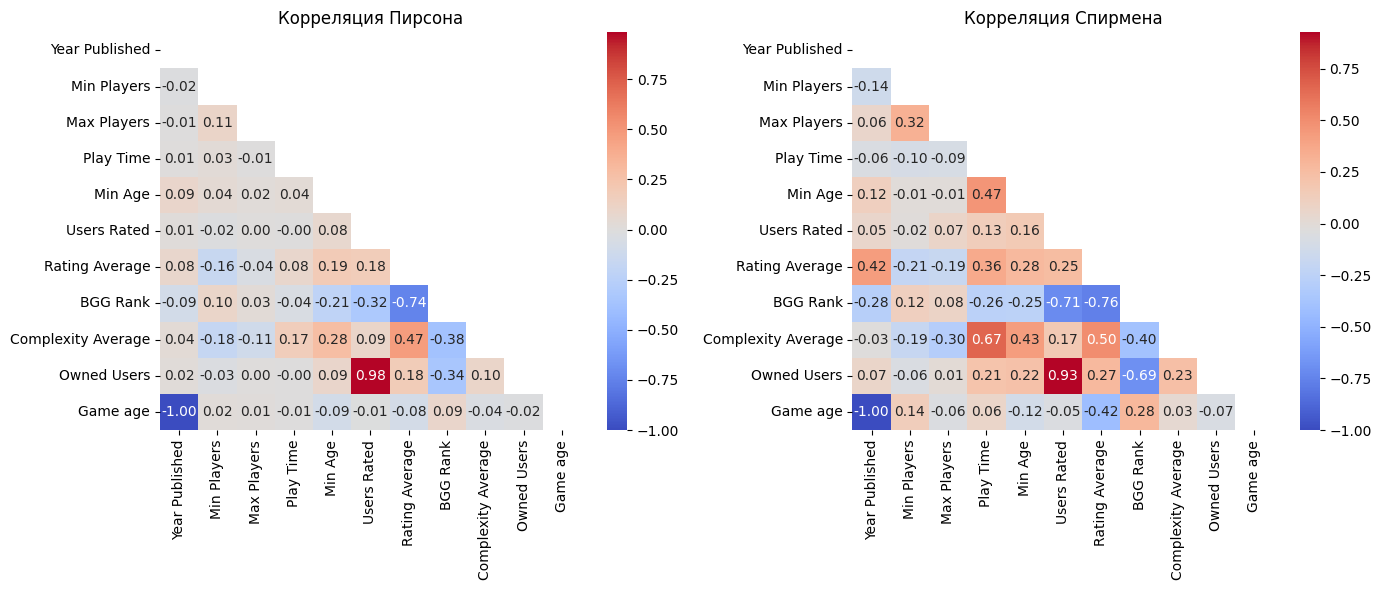

In [114]:
df = df_train.copy().drop(columns=cols_drop)
corr_pearson = df.corr(method='pearson', numeric_only=True)
corr_spearman = df.corr(method='spearman', numeric_only=True)

mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, ax=axes[0])
axes[0].set_title('Корреляция Пирсона')

sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, ax=axes[1])
axes[1].set_title('Корреляция Спирмена')

plt.tight_layout()
plt.show()

Линейные связи слабее нелинейных. Есть сильная положительная корреляция между количеством владельцев и числом оценок пользователей, что естественно

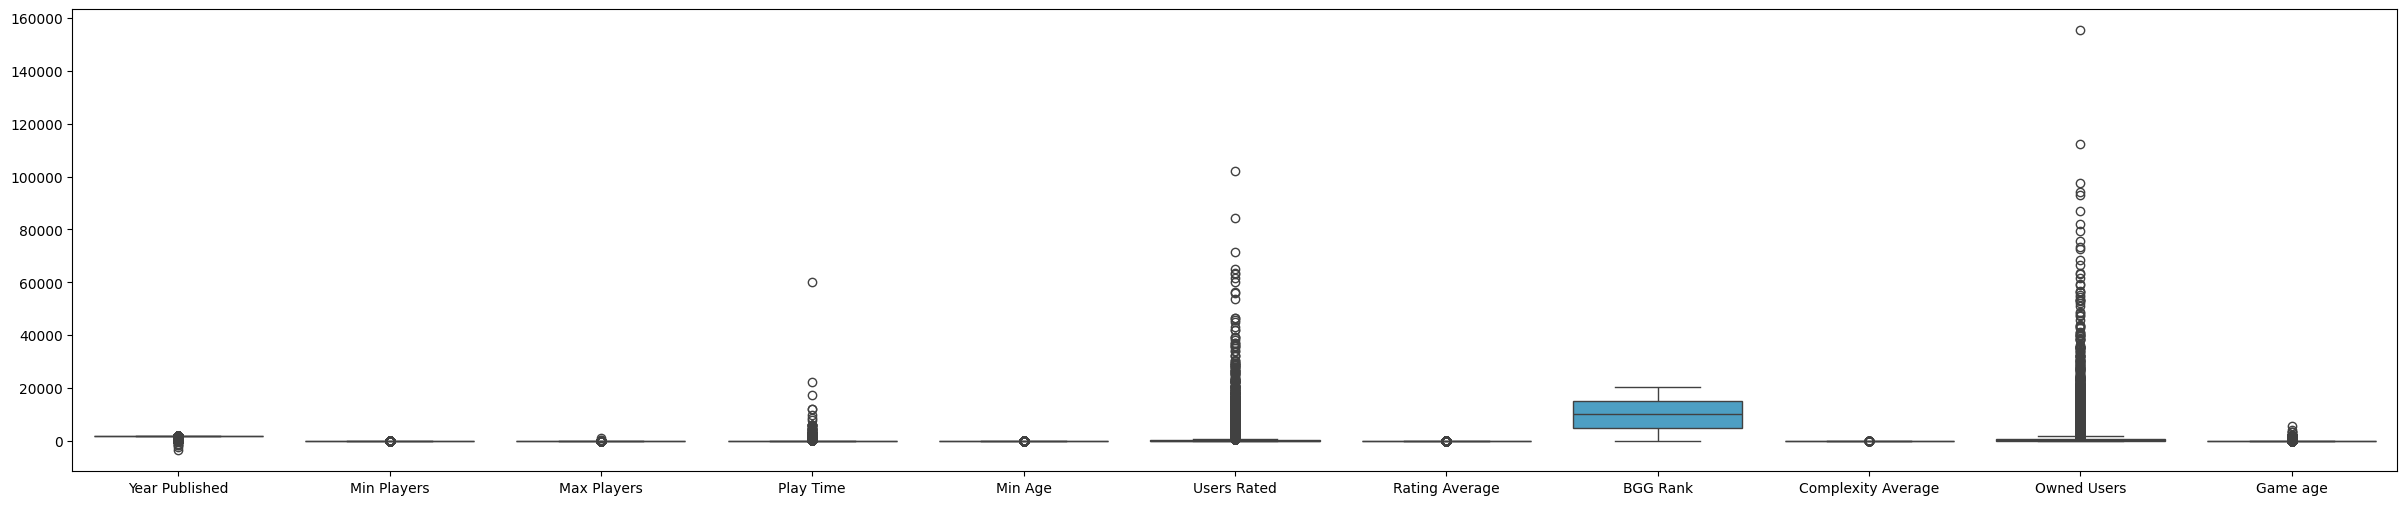

In [115]:
# fig, axes = plt.subplots(1, 3, figsize=(30, 6))

fig = plt.figure(figsize=(30, 6))

sns.boxplot(data=df)

plt.show()

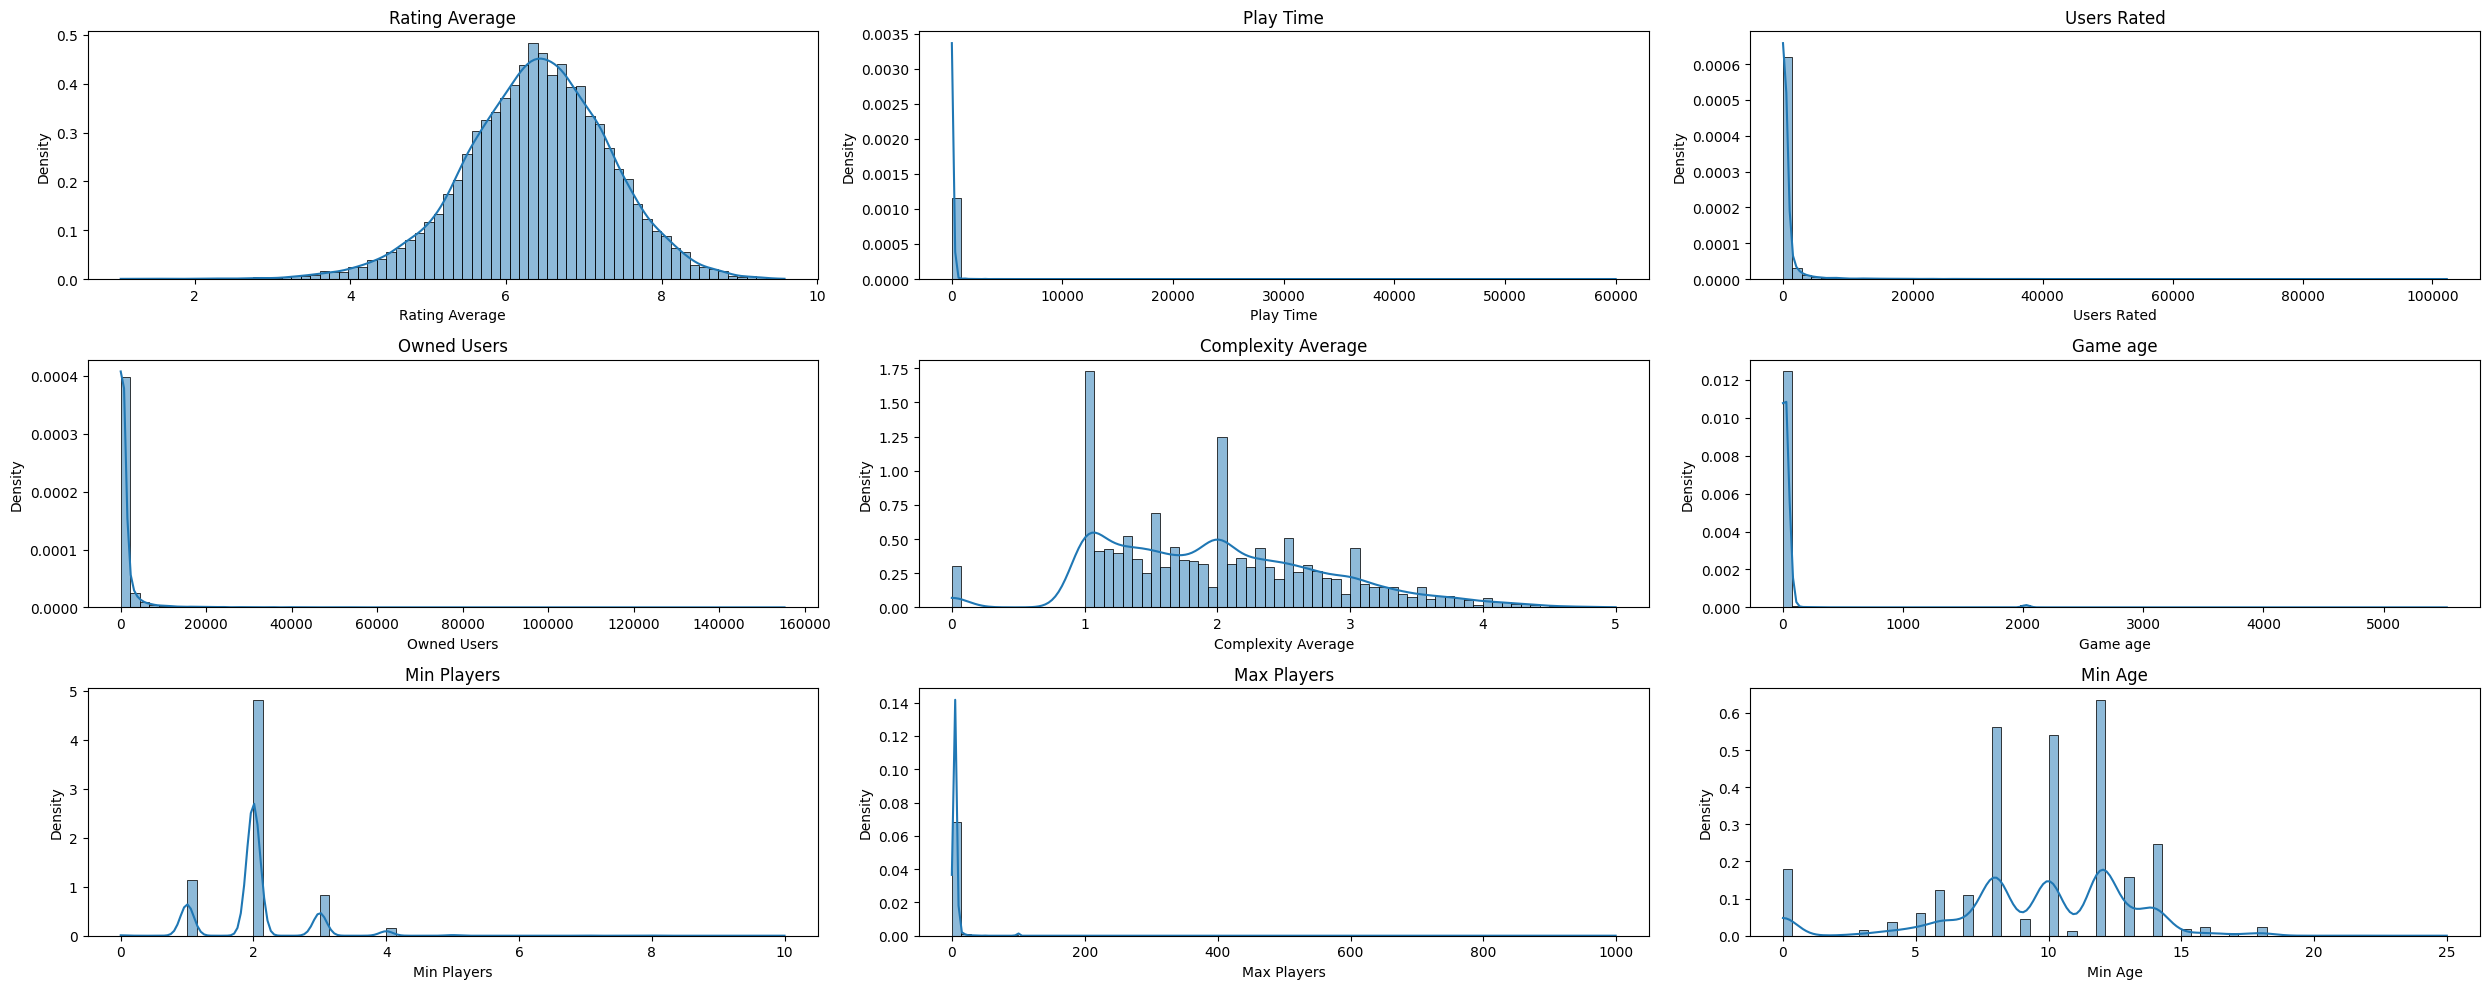

In [116]:
features = [
    'Rating Average',
    'Play Time',
    'Users Rated',
    'Owned Users',
    'Complexity Average',
    'Game age',
    'Min Players',
    'Max Players',
    'Min Age'
]

fig, axes = plt.subplots(3, 3, figsize=(25, 10))

for col, ax in zip(features, axes.flatten()):
    sns.histplot(
        df[col],
        bins=70,
        kde=True,
        stat='density',
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

Минимальное и максимальное число игроков, время игры, количество оценок очевидно имеют сильно скошенные распределения. Хорошим подходом будет их логарифмирование перед поиском выбросов

In [117]:
cols_log = [
    'Play Time',
    'Users Rated',
    'Owned Users',
    'Game age',
    'Max Players',
]

df_log = df[cols_log].apply(np.log1p)

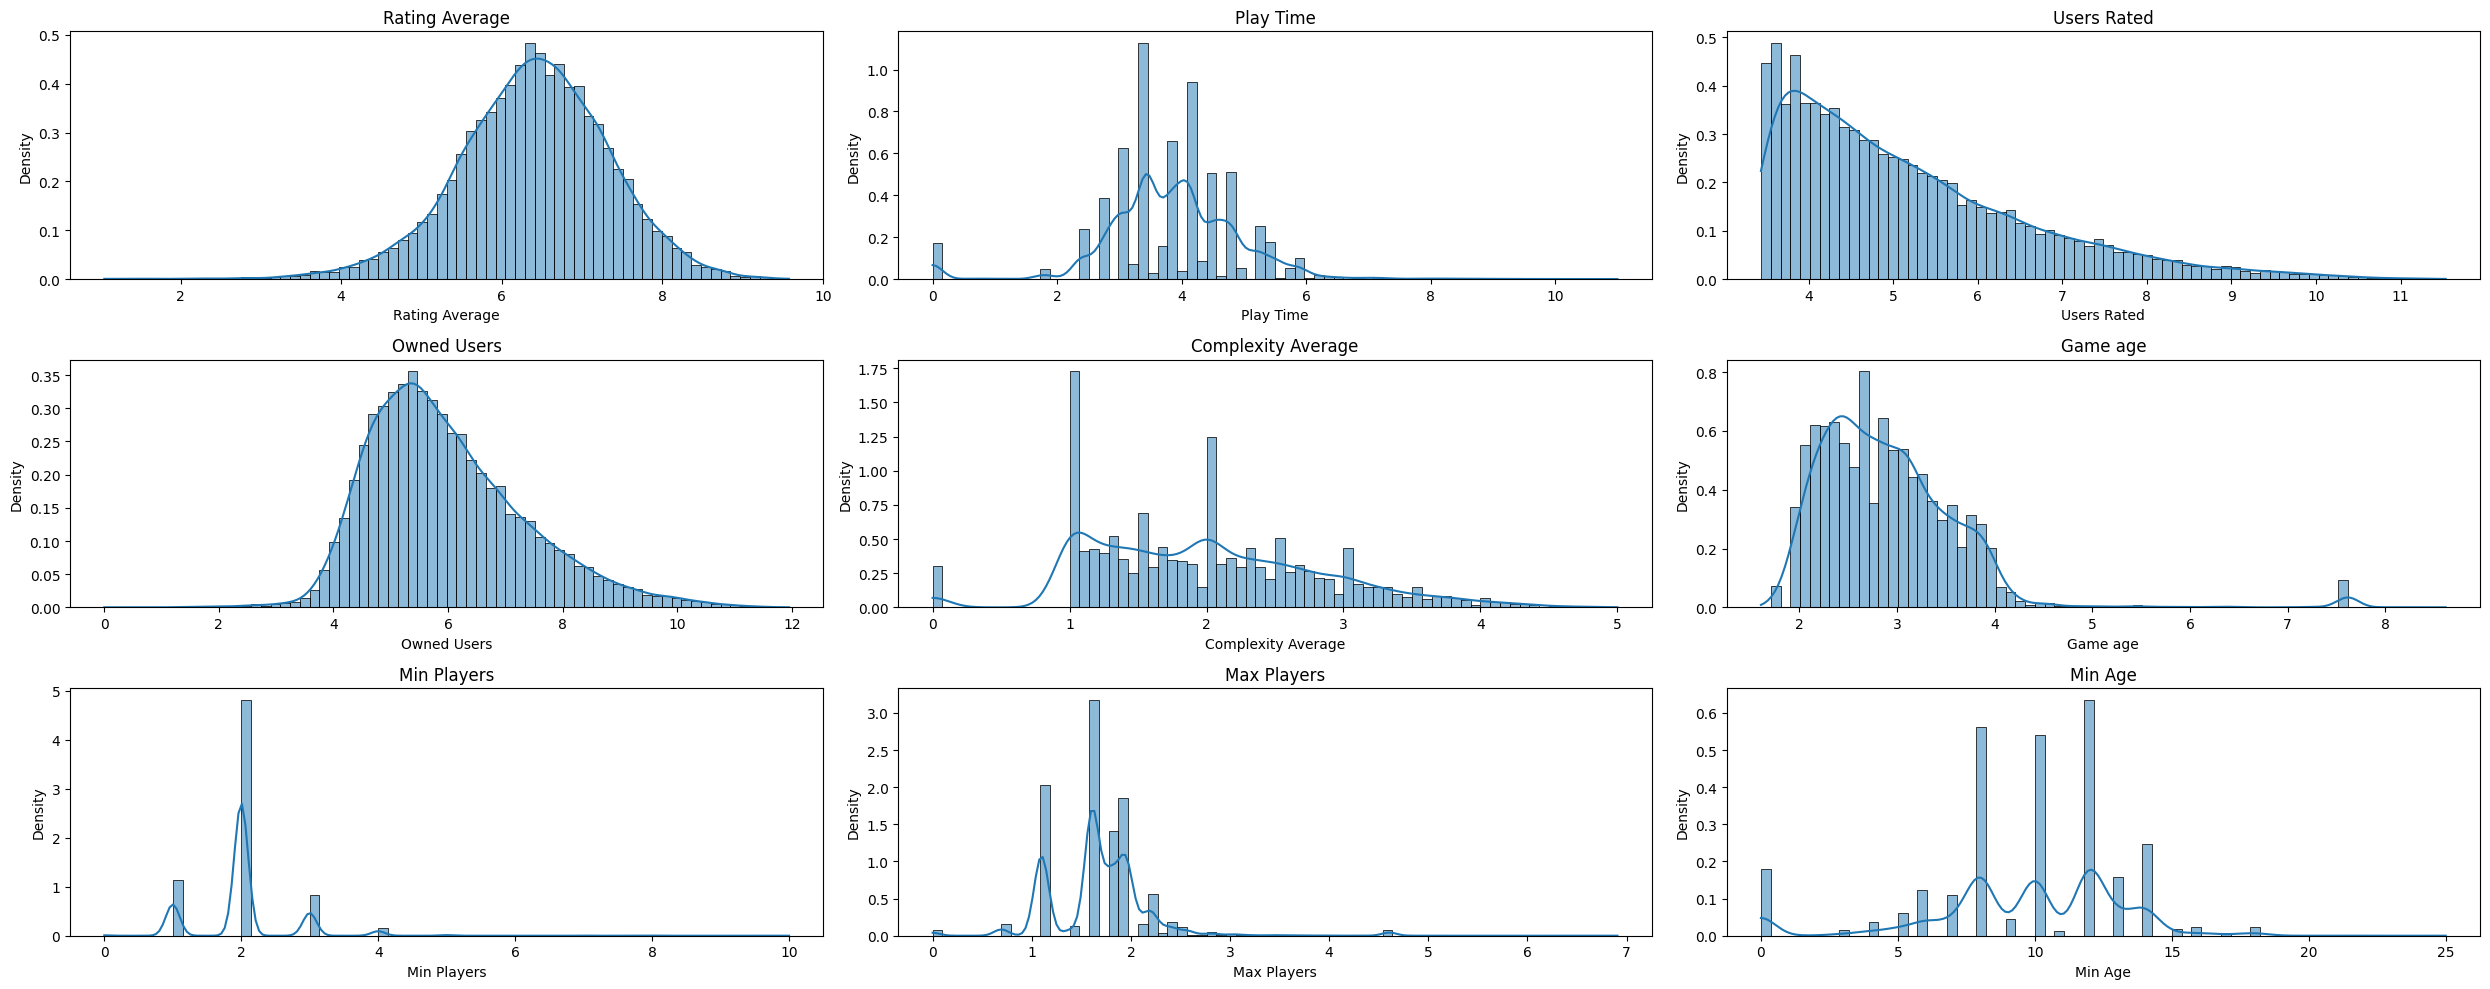

In [118]:
features = [
    'Rating Average',
    'Play Time',
    'Users Rated',
    'Owned Users',
    'Complexity Average',
    'Game age',
    'Min Players',
    'Max Players',
    'Min Age'
]

df_train_log = df_train.copy()
df_train_log[cols_log] = df_log

fig, axes = plt.subplots(3, 3, figsize=(25, 10))

for col, ax in zip(features, axes.flatten()):
    sns.histplot(
        df_train_log[col],
        bins=70,
        kde=True,
        stat='density',
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

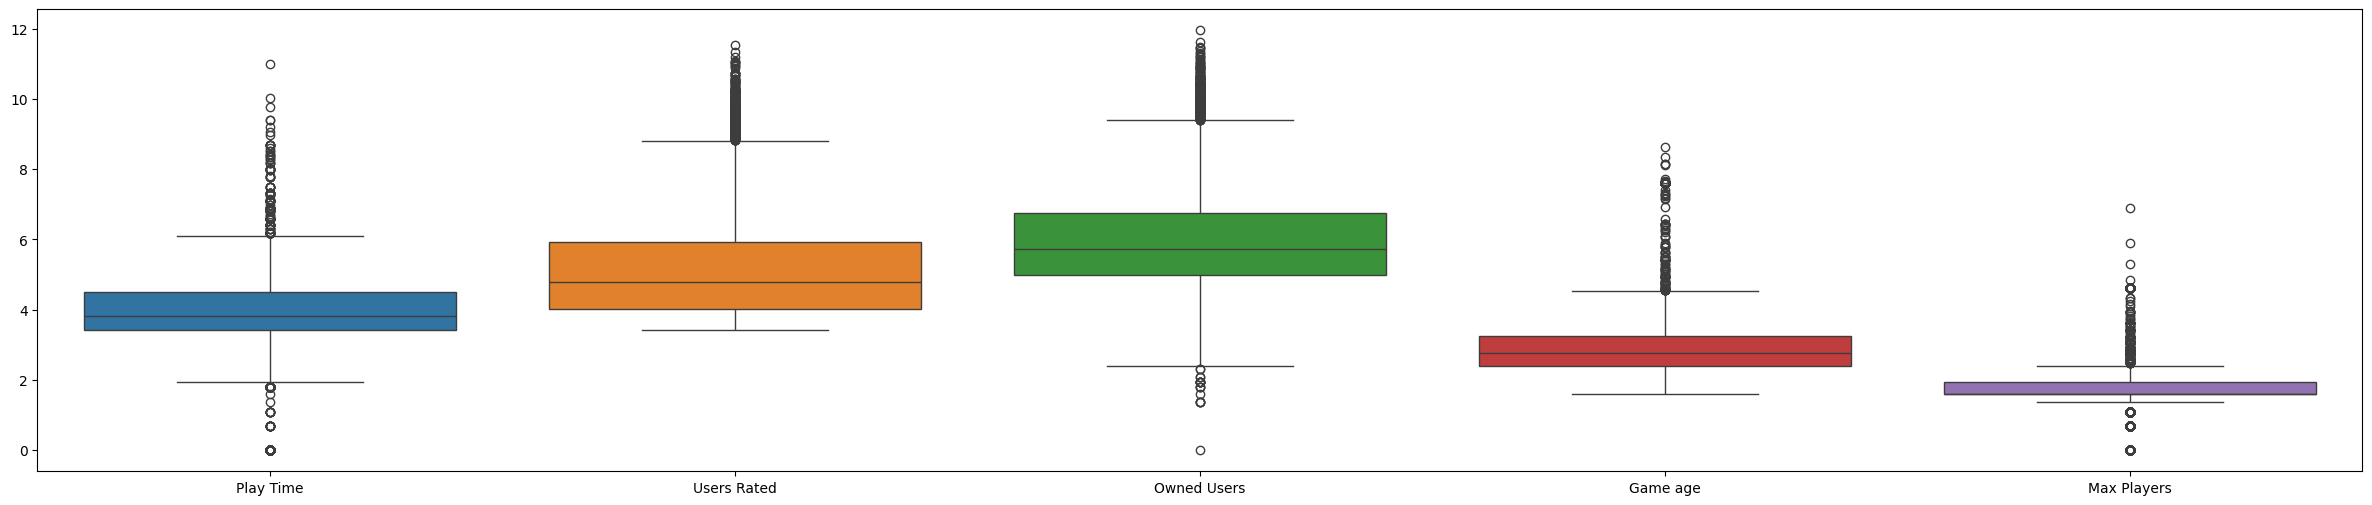

In [120]:
fig = plt.figure(figsize=(30, 6))

sns.boxplot(data=df_log)

plt.show()

После логарифмирования признаки стали гораздо симметричнее, и теперь можно анализировать выбросы

In [119]:
df_invalid = df[
    (df['Min Players'] < 1) |
    (df['Max Players'] < df['Min Players']) |
    (df['Play Time'] <= 0)
]

df_invalid

,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Game age
2107,0,0,0,0,0,804,6.90,2841,2.47,1194,NaN,2026
2398,2013,0,2,720,0,218,8.57,3224,3.74,699,"Dice Rolling, Hexagon Grid",13
2662,0,0,0,0,0,580,6.68,3589,1.70,2670,NaN,2026
3171,2016,2,0,60,0,199,8.15,4260,2.81,615,"Dice Rolling, Hexagon Grid, Simulation",10
3352,2008,2,0,240,0,292,6.97,4505,3.13,788,"Dice Rolling, Modular Board, Variable Player P...",18
...,...,...,...,...,...,...,...,...,...,...,...,...
15027,2009,2,0,60,12,244,4.84,20035,1.29,770,Roll / Spin and Move,17
15048,2011,2,2,0,0,41,1.43,20070,3.00,3,"Dice Rolling, Roll / Spin and Move",15
15121,2006,2,2,0,12,73,2.24,20168,1.00,202,NaN,20
15189,1920,2,0,5,0,225,3.79,20255,1.38,170,Set Collection,106


Есть довольно много строк с явными аномалиями - нулевое количество игроков, наибольшее количество игроков меньше наименьшего или время игры меньше нуля. Учтем это при обработке признаков

In [156]:
cols_number = [
    'Min Players',
    'Max Players',
    'Play Time',
    'Users Rated',
    'Complexity Average',
    'Owned Users',
    'Game age'
]

def process_outliers (df, cols=cols_number):
    df_copy = df.copy()

    # Если минимальное количество игроков меньше 1, делаем его равным 1
    if 'Min Players' in df_copy.columns:
        min_players_mask = df_copy['Min Players'] < 1
        df_copy.loc[min_players_mask, 'Min Players'] = 1

    # Если максимальное количество игроков меньше минимального, делаем максимальное равным минимальному
    if 'Max Players' in df_copy.columns and 'Min Players' in df_copy.columns:
        max_players_mask = df_copy['Max Players'] < df_copy['Min Players']
        df_copy.loc[max_players_mask, 'Max Players'] = df_copy.loc[max_players_mask, 'Min Players']

    # Вычисление межквартильного размаха и отсечение точек, которые лежат за пределами 1,5 IQR
    # Также пропуски заменяются медианой
    for col in df_copy.columns:
        s = df_copy[col]
        med = s.median()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df_copy[col] = np.where((s > upper) | (s < lower) | (s.isna()), med, s)

    return df_copy


Есть сильная линейная корреляция между количеством владельцев и количеством оценок пользователем. Применим метод главных компонент, чтобы получить 2 линейно независимых признака

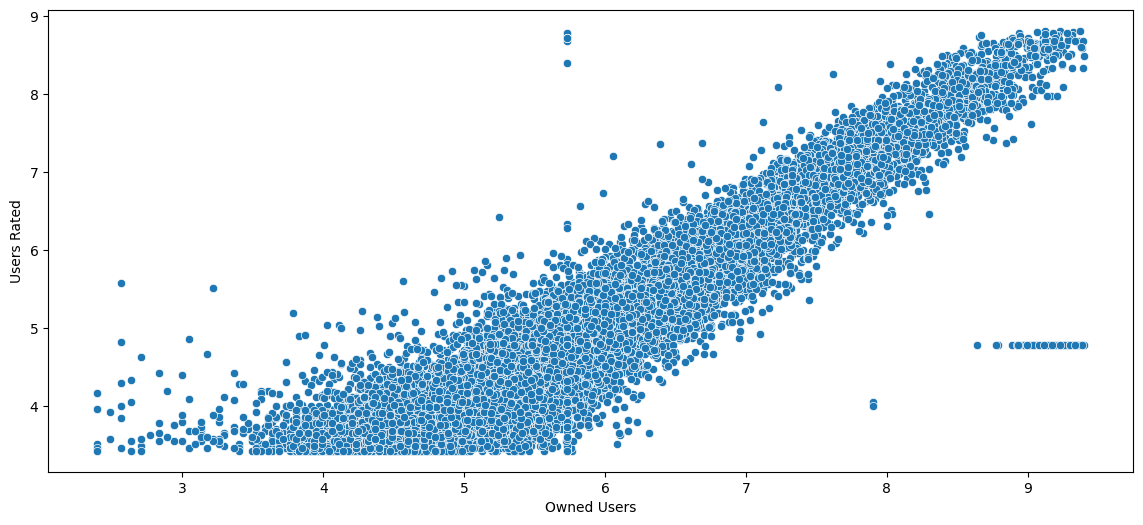

In [157]:
fig = plt.figure(figsize=(14, 6))

df_o = df[['Owned Users', 'Users Rated']].apply(np.log1p)

df_o = process_outliers(df_o, cols=['Owned Users', 'Users Rated'])

sns.scatterplot(data=df_o, x='Owned Users', y='Users Rated')

plt.show()

In [158]:
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(df_o)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.95395841 0.04604159]


Первый из новых признаков объясняет более 95% дисперсии, второй можно игнорировать, но, как показывают эксперименты, он все же дает заметный вклад, который чувствуется по изменению метрики MSE. Поэтому оставим оба

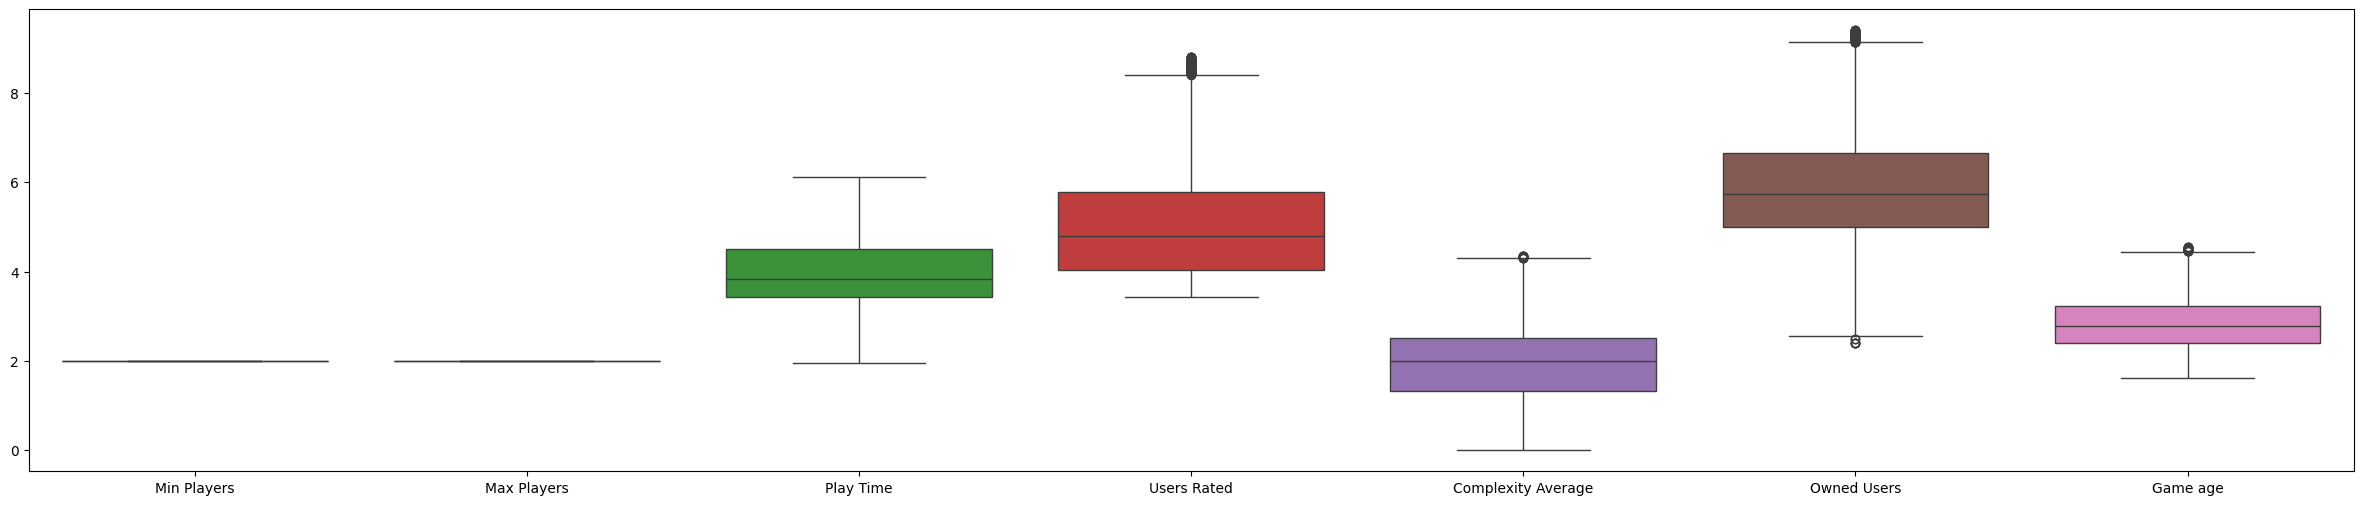

In [160]:
df_train_proc = process_outliers(df_train_log[cols_number])

fig = plt.figure(figsize=(30, 6))

sns.boxplot(data=df_train_proc)

plt.show()

Выполнена обработка пропусков и выбросов (простая стратегия - выбросом считается выходящее за 1,5 IQR). Дальше новый набор пайплайнов с трансформером. Эксперименты показали, что вторая главная компонента все же дает заметный прирост при обучении, поэтому ее стоит оставить. Применение PCA оправдано (результат без него хуже). Также учет колонок домена и рейтинга BGG дает существенное улучшение предсказаний, поэтому используется трансформер preprocessor_opt. Пропуски в доменах заполняются значением 'Unknown', которое кодируется в отдельную категорию. Заполнение пропусков медианой уже учтено в функции process_outliers, поэтому этот шаг исключен из пайплайна

In [161]:
cols_drop = ['ID', 'Name']

cols_number = [
    'Min Players',
    'Min Age',
    'Complexity Average'
]

cols_log = [
    'Play Time',
    'Game age',
    'Max Players'
    # 'Owned Users',
    # 'Users Rated'
]

cols_optional = ['BGG Rank']

cols_multilabel = [
    'Mechanics',
    'Domains'
]

cols_pca = ['Owned Users', 'Users Rated']

# Преобразование числовых признаков, которые остаются линейными
number_pipeline = Pipeline([
    ('outliers', FunctionTransformer(process_outliers)),
    # ('fill_na', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Преобразование числовых признаков с логарифмированием
log_pipeline = Pipeline([
    # ('fill_na', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('outliers', FunctionTransformer(process_outliers)),
    ('scaler', StandardScaler())
])

pca_pipeline = Pipeline([
    # ('fill_na', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('outliers', FunctionTransformer(process_outliers)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

# Преобразование признака механики
mechanics_pipeline = Pipeline([
    ('multilabel', MultiLabelTransformer())
])

# Преобразование признака домена
domains_pipeline = Pipeline([
    ('multilabel', MultiLabelTransformer())
])

# Общий предобработчик без опциональных признаков - указано, что делать для каждого типа колонок или отдельных колонок
preprocessor_min = ColumnTransformer([
    ('num', number_pipeline, cols_number),
    ('log_num', log_pipeline, cols_log),
    ('mechanics', mechanics_pipeline, ['Mechanics']),
    ('domains', domains_pipeline, ['Domains'])
],
remainder='drop')

# Аналогичный общий предобработчик c опциональными признаками
preprocessor_opt = ColumnTransformer([
    ('num', number_pipeline, cols_number + cols_optional),
    ('log_num', log_pipeline, cols_log),
    ('pca_users', pca_pipeline, cols_pca),
    ('mechanics', mechanics_pipeline, ['Mechanics']),
    ('domains', domains_pipeline, ['Domains'])
],
remainder='drop')

In [162]:
X = df_train.drop(columns=['Rating Average'] + cols_drop)
y = df_train['Rating Average']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [163]:
model_lin_reg = Pipeline([
    ('preprocessing', preprocessor_opt),
    ('regressor', LinearRegression())
])

model_lin_reg.fit(X_train, y_train)

y_pred = model_lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'R2: {r2:.4f}')

MSE: 0.2306
R2: 0.7421


Линейная регрессия дает заметно лучшие результаты, но все же она слишком неточна даже после обработки признаков

Параметры перебирались локально, здесь указаны найденные кодом ниже

In [183]:
model_rnd_forest = Pipeline([
    ('preprocessing', preprocessor_opt),
    ('regressor', RandomForestRegressor(
        n_estimators=500,
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1))
])

model_rnd_forest.fit(X_train, y_train)

y_pred = model_rnd_forest.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'R2: {r2:.4f}')

MSE: 0.0640
R2: 0.9284


In [165]:
# param_grid_rf = {
#     'regressor__n_estimators': [200, 300, 500],
#     'regressor__max_depth': [None, 10, 20],
#     'regressor__min_samples_split': [2, 5, 10],
#     'regressor__min_samples_leaf': [1, 2, 4]
# }

# grid_rf = GridSearchCV(
#     estimator=model_rnd_forest,
#     param_grid=param_grid_rf,
#     scoring='neg_root_mean_squared_error',
#     cv=5,
#     n_jobs=-1,
#     verbose=1,
#     refit=True
# )

# grid_rf.fit(X_train, y_train)

# print('Best params:', grid_rf.best_params_)
# print('Best CV RMSE:', -grid_rf.best_score_)

In [166]:
# param_grid_rf = {
#     'regressor__ccp_alpha': [0.0, 0.1, 0.2],
#     'regressor__max_features': [0.5, 0.75, 1.25],
#     'regressor__min_impurity_decrease': [0.1, 0.2, 0.4],
#     'regressor__max_samples': [0.2, 0.5, 1.0]
# }

# grid_rf = GridSearchCV(
#     estimator=Pipeline([
#     ('preprocessing', preprocessor_opt),
#     ('regressor', RandomForestRegressor(
#         n_estimators=500,
#         max_depth=20,
#         min_samples_split=2,
#         min_samples_leaf=2,
#         random_state=42,
#         n_jobs=-1))
#     ]),
#     param_grid=param_grid_rf,
#     scoring='neg_root_mean_squared_error',
#     cv=5,
#     n_jobs=-1,
#     verbose=1,
#     refit=True
# )

# grid_rf.fit(X_train, y_train)

# print('Best params:', grid_rf.best_params_)
# print('Best CV RMSE:', -grid_rf.best_score_)

Хороший результат, стоит посмотреть, что дадут другие методы

In [167]:
model_xgb = Pipeline([
    ('preprocessing', preprocessor_opt),
    ('regressor', XGBRegressor(
        objective='reg:squarederror',
        colsample_bytree=1.0,
        max_depth=5,
        subsample=0.8,
        n_estimators=700,
        learning_rate=0.05,

        min_child_weight=1,
        gamma=0.01,
        reg_alpha=1.2,
        reg_lambda=0.5,

        random_state=42,
        n_jobs=-1,
        tree_method='hist',


        grow_policy='lossguide'
        # max_leaves=31
    ))
])

model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'R2: {r2:.4f}')

MSE: 0.0567
R2: 0.9365


In [168]:
# param_grid_xgb = {
#     'regressor__n_estimators': [200, 500],
#     'regressor__max_depth': [3, 5, 7],
#     'regressor__learning_rate': [0.03, 0.05, 0.1],
#     'regressor__subsample': [0.8, 1.0],
#     'regressor__colsample_bytree': [0.8, 1.0],
#     'regressor__reg_lambda': [1, 5, 10]
# }

# grid_xgb = GridSearchCV(
#     estimator=model_xgb = Pipeline([
#     ('preprocessing', preprocessor_opt),
#     ('regressor', XGBRegressor(
#         objective='reg:squarederror',
#         colsample_bytree=1.0,
#         learning_rate=0.05,
#         max_depth=5,
#         n_estimators=500,
#         reg_lambda=1,
#         subsample=0.8,
#         random_state=42,
#         n_jobs=-1,
#         tree_method='hist'
#         )
#     )
#     ]),
#     param_grid=param_grid_xgb,
#     scoring='neg_root_mean_squared_error',
#     cv=5,
#     n_jobs=-1,
#     verbose=1,
#     refit=True
# )

# grid_xgb.fit(X_train, y_train)

# print('Best params:', grid_xgb.best_params_)
# print('Best CV RMSE:', -grid_xgb.best_score_)

In [169]:
# param_grid_xgb = {
#     'regressor__min_child_weight': [1, 3, 5, 10],
#     'regressor__gamma': [0, 0.01, 0.05],
#     'regressor__reg_lambda': [0.5, 0.7, 0.9],
#     'regressor__reg_alpha': [1.0, 1.2, 1.5],
#     'regressor__learning_rate': [0.01, 0.05, 0.1],
#     'regressor__n_estimators': [400, 500, 700],
# }

# grid_xgb = GridSearchCV(
#     estimator=Pipeline([
#     ('preprocessing', preprocessor_opt),
#     ('regressor', XGBRegressor(
#         objective='reg:squarederror',
#         colsample_bytree=1.0,
#         max_depth=5,
#         subsample=0.8,
#         random_state=42,
#         n_jobs=-1,
#         tree_method='hist'
#         )
#     )
#     ]),
#     param_grid=param_grid_xgb,
#     scoring='neg_root_mean_squared_error',
#     cv=5,
#     n_jobs=-1,
#     verbose=1,
#     refit=True
# )

# grid_xgb.fit(X_train, y_train)

# print('Best params:', grid_xgb.best_params_)
# print('Best CV RMSE:', -grid_xgb.best_score_)

Лучший результат дает XGBoost, но можно его немного улучшить за счет стекинга с регрессией методом случайного леса

In [171]:
model_svr = Pipeline([
    ('preprocessing', preprocessor_opt),
    ('regressor', SVR(
            C=100.0,
            epsilon=0.1,
            gamma=0.01,
            kernel='rbf',
        )
    )
])

model_svr.fit(X_train, y_train)

y_pred = model_svr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'R2: {r2:.4f}')

MSE: 0.1057
R2: 0.8818


In [172]:
# param_grid_svr = {
#     'regressor__kernel': ['rbf', 'linear'],
#     'regressor__C': [0.1, 1, 10, 100],
#     'regressor__epsilon': [0.01, 0.05, 0.1, 0.2],
#     'regressor__gamma': ['scale', 'auto', 0.01, 0.1, 1]
# }

# grid_svr = GridSearchCV(
#     estimator=model_svr,
#     param_grid=param_grid_svr,
#     scoring='neg_root_mean_squared_error',
#     cv=5,
#     n_jobs=-1,
#     verbose=1,
#     refit=True
# )

# grid_svr.fit(X_train, y_train)

# print('Best params:', grid_svr.best_params_)
# print('Best CV RMSE:', -grid_svr.best_score_)

Регрессор SVM не дает достаточно хорошего результата, чтобы его стоило использовать в стекинге. Экспериментально проверено, что его включение ухудшает метрику. Выгоднее всего взять случайный лес и XGBoost для стекинга, так как они дают близкие результаты по точности. Итоговый результат лучше каждого из отдельных

In [173]:
stack_model = StackingRegressor(
    estimators=[
        ('rf', model_rnd_forest),
        ('xgb', model_xgb)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

stack_model.fit(X_train, y_train)

y_pred = stack_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Stacking MSE: {mse:.4f}')
print(f'Stacking R2: {r2:.4f}')

Stacking MSE: 0.0529
Stacking R2: 0.9408


In [182]:
y_pred = stack_model.predict(df_test)

submit = pd.DataFrame(y_pred, columns=['Rating Average'])
submit = submit.reset_index()
submit.to_csv('game_regress.csv', index=False)

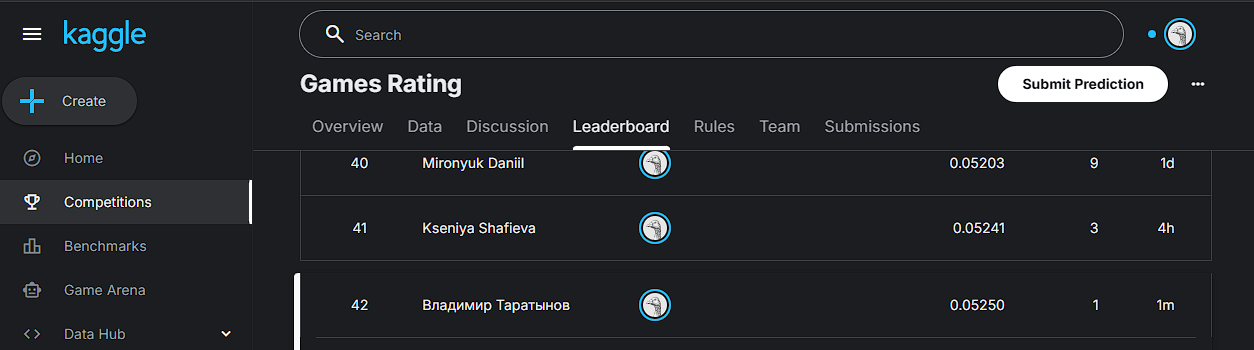